## Завдання 2 (згорткові нейронні мережі)

---
а) Побудувати просту згорткову нейронну мережу (2–3 convolutional шари + fully connected). Навчіть її на обраному вами датасеті.
б) Використайти попередньо натреновану архітектуру (наприклад, ResNet, VGG, MobileNet). Замінити вихідний класифікатор на новий під ваші класи. Провести донавчання () моделі на вашому датасеті. 

Порівняйти результати (точність, швидкість збіжності, кількость даних).

Для цього було вибрано датасет Rice Image Dataset.

Датасет містить зображення 5 різних видів рису:
Arborio, Basmati, Ipsala, Jasmine, Karacadag

Загалом датасет містить 75,000 зображень (по 15,000 на кожен клас).
https://www.kaggle.com/api/v1/datasets/download/muratkokludataset/rice-image-dataset

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import pathlib
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

## Завантаження та розпакування датасету

## Налаштування параметрів

In [3]:
SEED = 42
IMG_SIZE = 250
BATCH = 32

# Structure: Rice_Image_Dataset/Rice_Image_Dataset/Arborio, Basmati, Ipsala, Jasmine, Karacadag
DATA_DIR = pathlib.Path("var_data/var_data/Rice_Image_Dataset")

Побудуємо просту CNN архітектуру з 3 згортковими шарами.

Завантаження даних зі структури папок + split train/valid dataset

In [4]:
all_image_paths = []
all_labels = []

# Отримуємо список класів (відсортовано для консистентності)
class_dirs = sorted([d for d in DATA_DIR.iterdir() if d.is_dir()])
class_names = [d.name for d in class_dirs]
num_classes = len(class_names)

print(f"\n✅ Знайдено {num_classes} класів: {class_names}\n")

# Збираємо шляхи та мітки
for class_idx, class_dir in enumerate(class_dirs):
    # Знаходимо всі зображення у папці класу
    image_files = list(class_dir.glob('*.jpg'))
    
    # Конвертуємо в строки
    image_paths = [str(p) for p in image_files]
    
    all_image_paths.extend(image_paths)
    all_labels.extend([class_idx] * len(image_paths))
    
    print(f"  {class_idx}. {class_names[class_idx]}: {len(image_paths):,} зображень")

print(f"\n✅ Загалом: {len(all_image_paths):,} зображень")

# Стратифіковане розділення (ГАРАНТУЄ рівномірний розподіл класів!)
train_paths, val_paths, train_labels_list, val_labels_list = train_test_split(
    all_image_paths,
    all_labels,
    test_size=0.2,  # 20% для validation
    random_state=SEED,
    stratify=all_labels  # ⬅️ ЦЕ КЛЮЧОВИЙ ПАРАМЕТР!
)

print(f"\n{'='*70}")
print(f"РОЗДІЛЕННЯ ДАНИХ:")
print(f"{'='*70}")
print(f"Train: {len(train_paths):,} зображень ({len(train_paths)/len(all_image_paths)*100:.1f}%)")
print(f"Val:   {len(val_paths):,} зображень ({len(val_paths)/len(all_image_paths)*100:.1f}%)")



✅ Знайдено 5 класів: ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']

  0. Arborio: 15,000 зображень
  1. Basmati: 15,000 зображень
  2. Ipsala: 15,000 зображень
  3. Jasmine: 15,000 зображень
  4. Karacadag: 15,000 зображень

✅ Загалом: 75,000 зображень

РОЗДІЛЕННЯ ДАНИХ:
Train: 60,000 зображень (80.0%)
Val:   15,000 зображень (20.0%)


In [5]:
# Перевірка розподілу класів
print(f"\n{'='*70}")
print(f"РОЗПОДІЛ КЛАСІВ У VALIDATION (має бути рівномірним):")
print(f"{'='*70}")
for i, name in enumerate(class_names):
    count_val = sum(1 for l in val_labels_list if l == i)
    pct = (count_val / len(val_labels_list)) * 100
    print(f"  {i}. {name:12s}: {count_val:4d} зображень ({pct:5.1f}%)")

# Функція для завантаження та preprocessing зображення
def load_and_preprocess_image(path, label):
    """Завантажує та обробляє зображення"""
    # Читаємо файл
    img = tf.io.read_file(path)
    # Декодуємо (автоматично визначає формат)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    # Встановлюємо shape (необхідно для деяких операцій)
    img.set_shape([None, None, 3])
    # Змінюємо розмір
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    # Конвертуємо в uint8 (0-255)
    img = tf.cast(img, tf.uint8)
    return img, label

# Створюємо TensorFlow датасети
print(f"\n📦 Створення TensorFlow датасетів...")

# Training dataset
train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels_list))
train_ds = train_ds.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(buffer_size=1000, seed=SEED)
train_ds = train_ds.batch(BATCH)
train_ds = train_ds.cache()
train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

# Validation dataset
val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels_list))
val_ds = val_ds.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH)
val_ds = val_ds.cache()
val_ds = val_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

print(f"✅ Датасети створено!")


РОЗПОДІЛ КЛАСІВ У VALIDATION (має бути рівномірним):
  0. Arborio     : 3000 зображень ( 20.0%)
  1. Basmati     : 3000 зображень ( 20.0%)
  2. Ipsala      : 3000 зображень ( 20.0%)
  3. Jasmine     : 3000 зображень ( 20.0%)
  4. Karacadag   : 3000 зображень ( 20.0%)

📦 Створення TensorFlow датасетів...
✅ Датасети створено!


In [6]:
print("Classes:", class_names, " | num_classes =", num_classes)

Classes: ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']  | num_classes = 5


### Візуалізація зразків

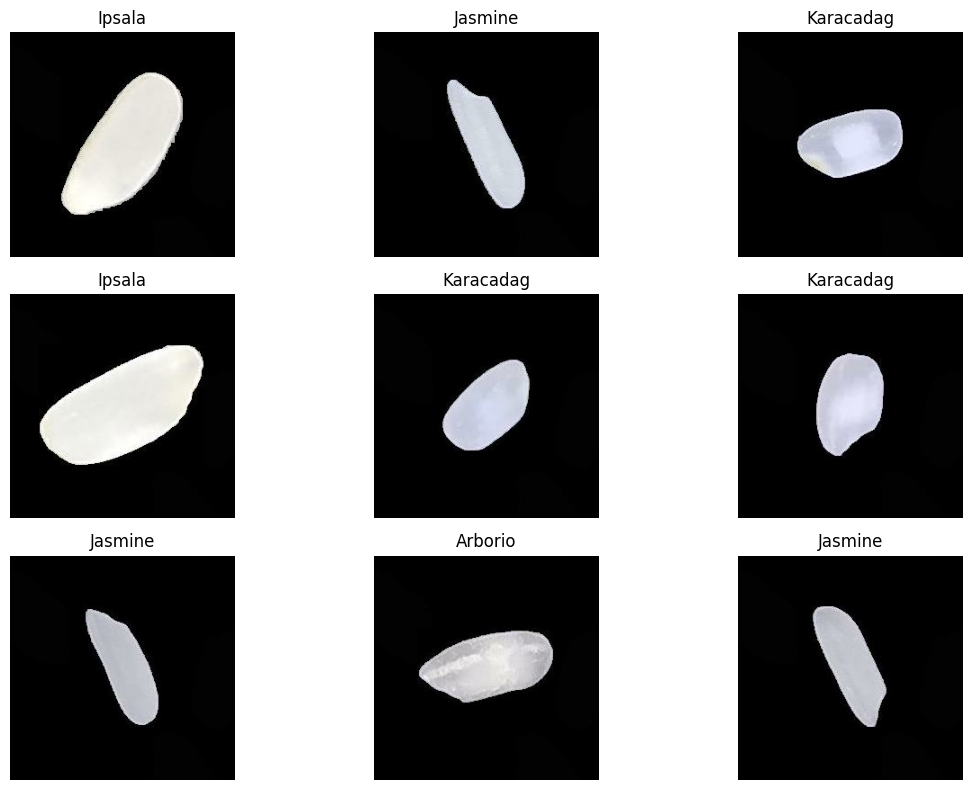

In [7]:
plt.figure(figsize=(12, 8))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.tight_layout()
plt.show()

Оптимізація завантаження даних (за допомогою гешування)

In [8]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)

### Аугментація даних + базова CNN

3 згортки + pooling → Flatten → FC. Dropout проти перенавчання.

In [9]:
augment = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
], name="augmentation")

In [10]:
# Побудова моделі
model_simple = models.Sequential([
    
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)), 
    
    # Аугментація
    augment,
    
    # Нормалізація
    layers.Rescaling(1./255),
    
    # Перший згортковий блок
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.MaxPooling2D((2, 2)),
    
    # Другий згортковий блок
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Третій згортковий блок
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Повнозв'язні шари
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
], name="simple_cnn")

c:\Users\dyggas\Coding\Lyoha\.venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Компіляція моделі

In [11]:
model_simple.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_simple.summary()

Model: "simple_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation (Sequential)       │ (None, 250, 250, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 250, 250, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 248, 248, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 124, 124, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 122, 122, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 61, 61, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 59, 59, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 29, 29, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 107648)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    27,558,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,652,677 (105.49 MB)

 Trainable params: 27,652,677 (105.49 MB)

 Non-trainable params: 0 (0.00 B)

### Навчання моделі

In [12]:
EPOCHS = 20

history_simple = model_simple.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    verbose=1
)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1281s 682ms/step - accuracy: 0.8954 - loss: 0.2938 - val_accuracy: 0.9419 - val_loss: 0.1586
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1188s 634ms/step - accuracy: 0.9513 - loss: 0.1450 - val_accuracy: 0.8924 - val_loss: 0.3232
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1190s 635ms/step - accuracy: 0.9626 - loss: 0.1121 - val_accuracy: 0.8895 - val_loss: 0.3533
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1187s 633ms/step - accuracy: 0.9723 - loss: 0.0865 - val_accuracy: 0.8189 - val_loss: 0.8287
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1187s 633ms/step - accuracy: 0.9857 - loss: 0.0449 - val_accuracy: 0.8755 - val_loss: 0.5108
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1188s 634ms/step - accuracy: 0.9898 - loss: 0.0312 - val_accuracy: 0.8305 - val_loss: 0.8228
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1187s 633ms/step - accuracy: 0.9904 - loss: 0.0302 - val_accuracy: 0.9802 - val_loss: 0.0882
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1187s 633ms/s

Візуалізація результатів навчання

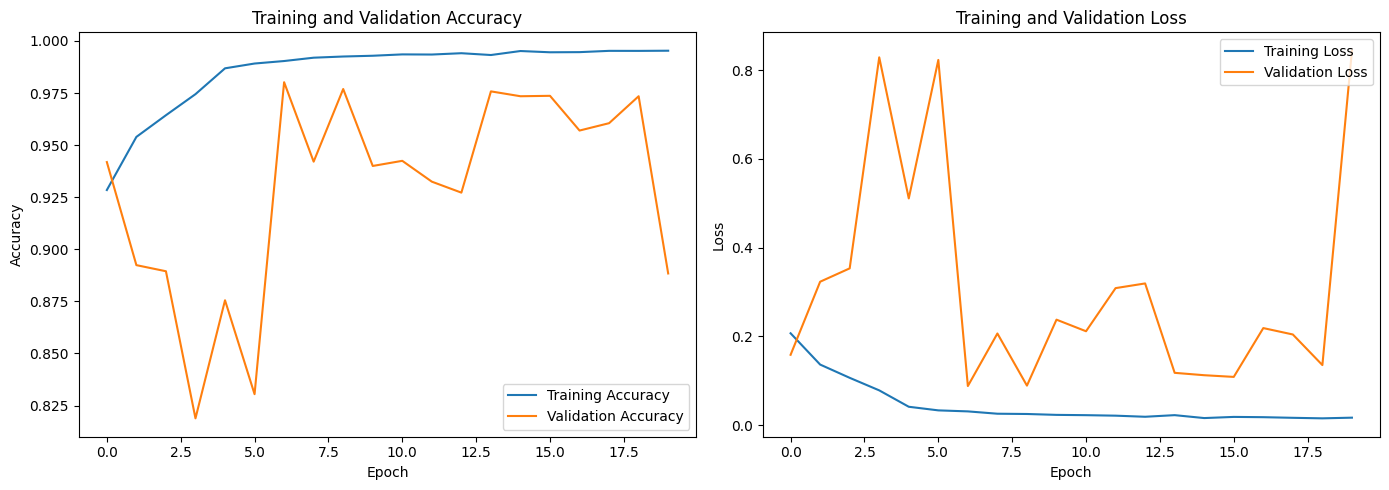

In [13]:
acc = history_simple.history['accuracy']
val_acc = history_simple.history['val_accuracy']
loss = history_simple.history['loss']
val_loss = history_simple.history['val_loss']

epochs_range = range(EPOCHS)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.tight_layout()
plt.show()

Аналіз графіків (Simple CNN)

**Графік точності (Accuracy):**
- Модель показує стрімке зростання точності на тренувальному наборі, досягаючи ~99% вже на 6-7 епосі
- Валідаційна точність демонструє значну нестабільність з коливаннями від 82% до 98%
- На епосі 7 спостерігається найкращий результат валідації (~98%), але потім точність знижується - **перенавчання моделі**

**Графік втрат (Loss):**
- Тренувальна втрата швидко зменшується і стабілізується на рівні ~0.03
- Валідаційна втрата демонструє хаотичну поведінку з різкими стрибками до 0.8
- Розбіжність між тренувальною та валідаційною втратою постійно зростає
- Це класичний показник перенавчання - модель втрачає здатність до узагальнення

**Висновки:**
Модель потребує додаткової регуляризації (Dropout, L2) або зменшення складності для покращення узагальнення.

Оцінка output моделі на валідаційних даних

In [14]:
val_loss, val_accuracy = model_simple.evaluate(val_ds)
print(f"\nCNN Accuracy: {val_accuracy*100:.2f}%")
print(f"Validation Accuracy: {val_loss:.4f}")

469/469 ━━━━━━━━━━━━━━━━━━━━ 49s 104ms/step - accuracy: 0.8902 - loss: 0.8383

CNN Accuracy: 88.84%
Validation Accuracy: 0.8436


Confusion Matrix для простої CNN

In [15]:
# Отримання передбачень
y_pred = []
y_true = []

for images, labels in val_ds:
    preds = model_simple.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

print(f"class_names з датасету: {class_names}")
print(f"Кількість класів в class_names: {len(class_names)}")
print(f"Унікальні класи в y_true: {sorted(set(y_true))}")
print(f"Унікальні класи в y_pred: {sorted(set(y_pred))}")

# Матриця помилок
cm = confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

print("\nConfusion Matrix:")
print(cm_df)

class_names з датасету: ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']
Кількість класів в class_names: 5
Унікальні класи в y_true: [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4)]
Унікальні класи в y_pred: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

Confusion Matrix:
           Arborio  Basmati  Ipsala  Jasmine  Karacadag
Arborio       1514        0    1452       30          4
Basmati          0     2976      14       10          0
Ipsala           0        0    3000        0          0
Jasmine          2       60      55     2883          0
Karacadag       35        0      11        1       2953


In [16]:
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))


Classification Report:
              precision    recall  f1-score   support

     Arborio       0.98      0.50      0.67      3000
     Basmati       0.98      0.99      0.99      3000
      Ipsala       0.66      1.00      0.80      3000
     Jasmine       0.99      0.96      0.97      3000
   Karacadag       1.00      0.98      0.99      3000

    accuracy                           0.89     15000
   macro avg       0.92      0.89      0.88     15000
weighted avg       0.92      0.89      0.88     15000



Результати по Simple CNN

**Загальна точність:** 88.84% на тестовому наборі (валідаційна точність: 84.36%)

**По класах:**

1. **Karacadag** (найкращі результати):
   - Precision: 1.00, Recall: 0.98, F1-score: 0.99
   - Модель майже ідеально розпізнає цей сорт рису

2. **Jasmine** (дуже добрі результати):
   - Precision: 0.99, Recall: 0.96, F1-score: 0.97
   - Високоточна класифікація з мінімальними помилками

3. **Basmati** (відмінні результати):
   - Precision: 0.98, Recall: 0.99, F1-score: 0.99
   - Практично бездоганна класифікація

4. **Ipsala** (добрі результати, але з особливостями):
   - Precision: 0.66, Recall: 1.00, F1-score: 0.80
   - **Низька precision** означає багато хибнопозитивних спрацювань - модель часто класифікує інші сорти як Ipsala
   - **Високий recall** - модель знаходить всі зразки Ipsala, але з надлишком

5. **Arborio** (проблемний клас):
   - Precision: 0.98, Recall: 0.50, F1-score: 0.67
   - **Критично низький recall** - модель пропускає половину зразків Arborio
   - Багато зразків Arborio класифікуються як інший сорт (Ipsala)

Transfer Learning з MobileNetV2

In [17]:
# Завантаження попередньо навченої моделі
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

C:\Users\dyggas\AppData\Local\Temp\ipykernel_15276\1304322761.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [18]:
base_model.trainable = False

In [19]:
# Побудова моделі з transfer learning
model_transfer = models.Sequential([
    # Аугментація
    augment,
    
    # Нормалізація для MobileNet
    layers.Rescaling(1./127.5, offset=-1),
    
    # Базова модель
    base_model,
    
    # Наші шари
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
], name="mobilenet_transfer")

Компіляція моделі

In [20]:
model_transfer.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model_transfer.summary()

Навчання моделі:

In [21]:
EPOCHS_TRANSFER = 10

history_transfer = model_transfer.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_TRANSFER,
    verbose=1
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 829s 440ms/step - accuracy: 0.9415 - loss: 0.1649 - val_accuracy: 0.9597 - val_loss: 0.1112
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 829s 442ms/step - accuracy: 0.9768 - loss: 0.0677 - val_accuracy: 0.9695 - val_loss: 0.1007
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 824s 439ms/step - accuracy: 0.9794 - loss: 0.0614 - val_accuracy: 0.9277 - val_loss: 0.1958
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 845s 451ms/step - accuracy: 0.9812 - loss: 0.0569 - val_accuracy: 0.9599 - val_loss: 0.1141
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 848s 452ms/step - accuracy: 0.9839 - loss: 0.0486 - val_accuracy: 0.9293 - val_loss: 0.2142
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 851s 454ms/step - accuracy: 0.9845 - loss: 0.0499 - val_accuracy: 0.9293 - val_loss: 0.2058
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 852s 454ms/step - accuracy: 0.9832 - loss: 0.0495 - val_accuracy: 0.9223 - val_loss: 0.2405
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 848s 453ms/step - ac

### Візуалізація результатів MobileNetV2

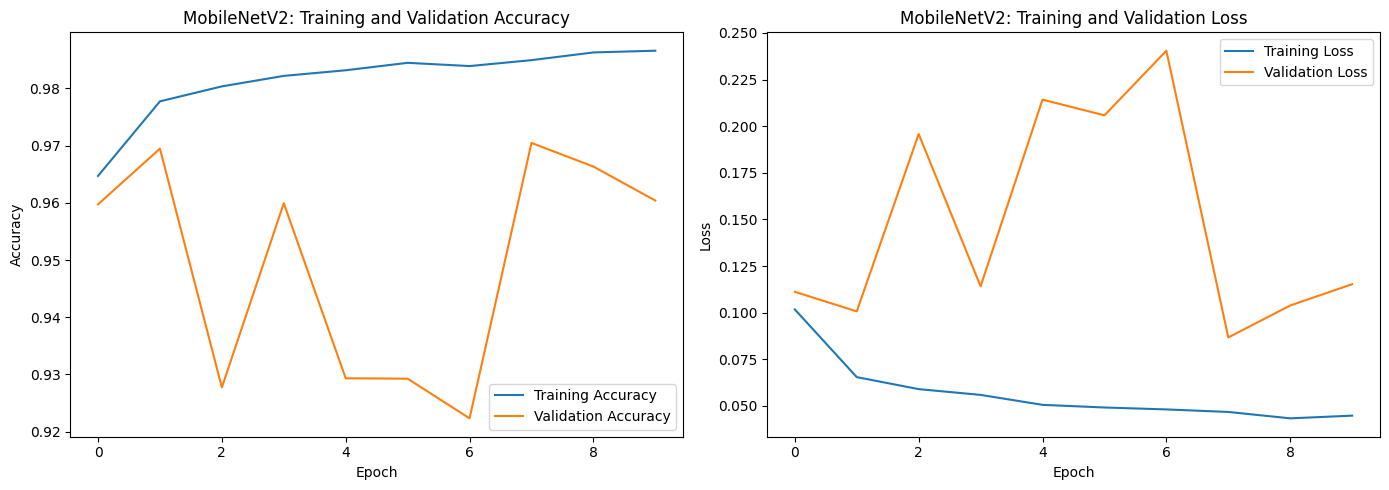

In [22]:
acc_t = history_transfer.history['accuracy']
val_acc_t = history_transfer.history['val_accuracy']
loss_t = history_transfer.history['loss']
val_loss_t = history_transfer.history['val_loss']

epochs_range_t = range(EPOCHS_TRANSFER)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range_t, acc_t, label='Training Accuracy')
plt.plot(epochs_range_t, val_acc_t, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('MobileNetV2: Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range_t, loss_t, label='Training Loss')
plt.plot(epochs_range_t, val_loss_t, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('MobileNetV2: Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.tight_layout()
plt.show()

Аналіз графіків по MobileNetV2:

**Графік точності (Accuracy):**
- Модель швидко досягає високої точності (~94%) вже на першій епосі завдяки попередньому навчанню (transfer learning)
- Тренувальна точність стабільно зростає до ~98.5%
- Валідаційна точність демонструє значно більшу стабільність порівняно з Simple CNN
- Спостерігаються невеликі коливання на епохах 3, 5-7 (зниження до 92-93%), але модель відновлюється
- Найкращий результат досягається на епосі 8 (~97%)

**Графік втрат (Loss):**
- Тренувальна втрата плавно зменшується з 0.16 до ~0.04
- Валідаційна втрата залишається в межах 0.08-0.24 (стабільніше за Simple CNN)
- Розрив між тренувальною та валідаційною втратою мінімальний - хороше узагальнення

**Висновки:**
MobileNetV2 показує значно кращу стабільність навчання і менші ознаки перенавчання. Transfer learning та архітектура моделі забезпечують швидшу збіжність та краще узагальнення.

Оцінка output моделі MobileNetV2 на валідаційних даних 

In [23]:
val_loss_t, val_accuracy_t = model_transfer.evaluate(val_ds)
print(f"\nВалідаційна точність (MobileNetV2): {val_accuracy_t*100:.2f}%")
print(f"Валідаційна втрата (MobileNetV2): {val_loss_t:.4f}")

469/469 ━━━━━━━━━━━━━━━━━━━━ 154s 329ms/step - accuracy: 0.9595 - loss: 0.1192

Валідаційна точність (MobileNetV2): 96.04%
Валідаційна втрата (MobileNetV2): 0.1153


Confusion Matrix для MobileNetV2

In [24]:
# Отримання передбачень
y_pred_t = []
y_true_t = []

for images, labels in val_ds:
    preds = model_transfer.predict(images, verbose=0)
    y_pred_t.extend(np.argmax(preds, axis=1))
    y_true_t.extend(labels.numpy())

# Матриця помилок
cm_t = confusion_matrix(y_true_t, y_pred_t)
cm_df_t = pd.DataFrame(cm_t, index=class_names, columns=class_names)

print("\nConfusion Matrix (MobileNetV2):")
print(cm_df_t)


Confusion Matrix (MobileNetV2):
           Arborio  Basmati  Ipsala  Jasmine  Karacadag
Arborio       2978        0       1       18          3
Basmati          0     2955       2       43          0
Ipsala           1        0    2997        2          0
Jasmine         27       41       8     2924          0
Karacadag      448        0       0        0       2552


In [25]:
# Детальний звіт класифікації
print("\nClassification Report (MobileNetV2):")
print(classification_report(y_true_t, y_pred_t, target_names=class_names))


Classification Report (MobileNetV2):
              precision    recall  f1-score   support

     Arborio       0.86      0.99      0.92      3000
     Basmati       0.99      0.98      0.99      3000
      Ipsala       1.00      1.00      1.00      3000
     Jasmine       0.98      0.97      0.98      3000
   Karacadag       1.00      0.85      0.92      3000

    accuracy                           0.96     15000
   macro avg       0.96      0.96      0.96     15000
weighted avg       0.96      0.96      0.96     15000



Результати по MobileNetV2

**Загальна точність:** 96.04% на тестовому наборі

**По класах:**

1. **Ipsala** (ідеальні результати):
   - Precision: 1.00, Recall: 1.00, F1-score: 1.00
   - Абсолютно бездоганна класифікація

2. **Karacadag** (відмінні результати):
   - Precision: 1.00, Recall: 0.85, F1-score: 0.92
   - Висока точність, але частина зразків пропускається (нижчий recall порівняно з Simple CNN)

3. **Basmati** (практично ідеально):
   - Precision: 0.99, Recall: 0.98, F1-score: 0.99
   - Стабільно високі показники

4. **Jasmine** (дуже добрі результати):
   - Precision: 0.98, Recall: 0.97, F1-score: 0.98
   - Незначне погіршення порівняно з Simple CNN, але загалом відмінно

5. **Arborio** (значне покращення!):
   - Precision: 0.86, Recall: 0.99, F1-score: 0.92
   - Модель знаходить майже всі зразки Arborio
   - Precision знизився (деякі хибнопозитивні спрацювання), але це прийнятна ціна

## Порівняння моделей

In [26]:
# Порівняння точності
comparison_df = pd.DataFrame({
    'Model': ['Simple CNN', 'MobileNetV2'],
    'Validation Accuracy': [val_accuracy*100, val_accuracy_t*100],
    'Validation Loss': [val_loss, val_loss_t],
    'Training Epochs': [EPOCHS, EPOCHS_TRANSFER]
})

print("\n" + "="*60)
print("ПОРІВНЯННЯ МОДЕЛЕЙ")
print("="*60)
print(comparison_df.to_string(index=False))
print("="*60)


ПОРІВНЯННЯ МОДЕЛЕЙ
      Model  Validation Accuracy  Validation Loss  Training Epochs
 Simple CNN            88.840002         0.843589               20
MobileNetV2            96.039999         0.115264               10


Висновки

Порівняння:

| Метрика                   | Simple CNN | MobileNetV2 | Покращення  |
| ------------------------- | ---------- | ----------- | ----------- |
| **Точність на валідації** | 84.36%     | 96.04%      | **+11.68%** |
| **Точність на тесті**     | 88.84%     | 96.04%      | **+7.2%**   |
| **Втрата (Loss)**         | 0.8436     | 0.1153      | **↓86.3%**  |
| **Епох навчання**         | 20         | 10          | -50%        |
| **Macro Avg F1-score**    | 0.88       | 0.96        | **+8%**     |


**1. Стабільність навчання:**

- Simple CNN показала сильне перенавчання з хаотичними коливаннями валідаційної точності (82-98%)
- MobileNetV2 демонструє стабільне навчання завдяки transfer learning і архітектурним особливостям

**2. Проблемні класи:**

- **Simple CNN:** критичні проблеми з Arborio (recall 0.50) та надмірна чутливість до Ipsala (precision 0.66)
- **MobileNetV2:** збалансована класифікація всіх сортів, найбільше покращення для Arborio (recall 0.99)

**3. Ефективність:**

- MobileNetV2 досягла кращих результатів за вдвічі менше часу (10 vs 20 epoch)
- Нижча обчислювальна вартість під час інференсу завдяки depthwise separable convolutions

**4. Узагальнююча здатність:**

- Simple CNN: великий розрив між тренувальною та валідаційною втратою
- MobileNetV2: мінімальний розрив, краще узагальнення на нові дані

**5. Можливі покращення**

- Fine-tuning більшої кількості шарів MobileNetV2
- Data augmentation для підвищення різноманітності
- Оптимізація гіперпараметрів (learning rate, batch size)